# app

07 - Active Brazing Trigger

Отдельное исследование триггера начала активной пайки.

Цель:

1. Использовать предсказания финального stage-classifier.
2. Проверить, можно ли получить триггер начала `active_brazing` из вероятности `P(active_brazing)`.
3. Проверить CV-trigger на признаках OpenCV.
4. Проверить classical ML binary-trigger на OpenCV-признаках.
5. Оценивать не только покадровые метрики, но и ошибку времени срабатывания.

Событие:

```text
active_brazing_started = момент начала стадии active_brazing

## bootstrap

In [1]:
import os
from pathlib import Path

def is_colab() -> bool:
    try:
        import google.colab  # type: ignore
        return True
    except ImportError:
        return False
    

IN_COLAB = is_colab()

if IN_COLAB:
    REPO_ROOT = Path("/content") / "BrazingSense"
else:
    REPO_ROOT = Path.cwd().resolve()

if not (REPO_ROOT / ".git").exists():
    raise RuntimeError(f"REPO_ROOT не похож на корень репозитория: {REPO_ROOT}")

os.chdir(REPO_ROOT)

## packages

In [2]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

## env

In [3]:
FPS = 10
ROOT = Path()
DRIVE_FOLDER = Path('/content/drive/MyDrive/Colab Notebooks/Diploma')

In [5]:
DATA = ROOT / "data" 

DATA_ANNOTATIONS = DATA / "annotations" 
STAGE_INTERVALS_PATH = DATA_ANNOTATIONS / "stage_intervals.csv"

SPLITS_DIR = DATA / "annotations" / f"splits_{FPS}"
TRAIN_PATH = SPLITS_DIR / "train.csv"
VAL_PATH = SPLITS_DIR / "val.csv"
TEST_PATH = SPLITS_DIR / "test.csv"

assert STAGE_INTERVALS_PATH.exists(), STAGE_INTERVALS_PATH
assert TRAIN_PATH.exists(), TRAIN_PATH
assert VAL_PATH.exists(), VAL_PATH
assert TEST_PATH.exists(), TEST_PATH

In [6]:
REPORTS = ROOT / "reports" 

STAGE_PREDICTIONS_PATH = REPORTS / f"final_neural_stage_classification_{FPS}" / f"resnet18_base_test_predictions_{FPS}.csv"
CV_FEATURES_PATH = REPORTS / "cv_features_10" / "frame_features_roi.csv"

OUTPUT_DIR = REPORTS / "active_brazing_trigger"
FIGURES_DIR = REPORTS / "figures" / "active_brazing_trigger"

assert STAGE_PREDICTIONS_PATH.exists(), STAGE_PREDICTIONS_PATH
assert CV_FEATURES_PATH.exists(), STAGE_PREDICTIONS_PATH
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [7]:
STAGE_ORDER = [
    "inactive_preparation",
    "flux_activation",
    "active_brazing",
    "stabilization",
]

STAGE_TO_ID = {
    "inactive_preparation": 0,
    "flux_activation": 1,
    "active_brazing": 2,
    "stabilization": 3,
}

ID_TO_STAGE = {v: k for k, v in STAGE_TO_ID.items()}

ACTIVE_STAGE_ID = STAGE_TO_ID["active_brazing"]

# lib

# model

# runtime

## trigger: stage-model probabilities

In [8]:
pred_df = pd.read_csv(STAGE_PREDICTIONS_PATH)
pred_df = pred_df.sort_values(["video_id", "timestamp_s"]).reset_index(drop=True)

print(pred_df.shape)
pred_df.head()

(1732, 11)


,video_id,frame_path,timestamp_s,stage_name,stage_id,pred_stage_id,pred_stage_name,prob_inactive_preparation,prob_flux_activation,prob_active_brazing,prob_stabilization
0,MVI_6265,data/processed/frames_10/MVI_6265/MVI_6265_000...,0.0,inactive_preparation,0,0,inactive_preparation,0.689079,0.167046,0.072961,0.070914
1,MVI_6265,data/processed/frames_10/MVI_6265/MVI_6265_000...,0.1,inactive_preparation,0,1,flux_activation,0.318643,0.434341,0.107281,0.139735
2,MVI_6265,data/processed/frames_10/MVI_6265/MVI_6265_000...,0.2,inactive_preparation,0,0,inactive_preparation,0.467962,0.320719,0.114499,0.096820
3,MVI_6265,data/processed/frames_10/MVI_6265/MVI_6265_000...,0.3,inactive_preparation,0,0,inactive_preparation,0.489105,0.242795,0.184225,0.083875
4,MVI_6265,data/processed/frames_10/MVI_6265/MVI_6265_000...,0.4,inactive_preparation,0,0,inactive_preparation,0.779270,0.067154,0.088990,0.064586


### check prob

In [9]:
prob_columns = [f"prob_{stage}" for stage in STAGE_ORDER]
missing_probs = [col for col in prob_columns if col not in pred_df.columns]

if missing_probs:
    raise ValueError(f"Missing probability columns: {missing_probs}")

pred_df[prob_columns].head()

,prob_inactive_preparation,prob_flux_activation,prob_active_brazing,prob_stabilization
0,0.689079,0.167046,0.072961,0.070914
1,0.318643,0.434341,0.107281,0.139735
2,0.467962,0.320719,0.114499,0.096820
3,0.489105,0.242795,0.184225,0.083875
4,0.779270,0.067154,0.088990,0.064586


### load true active_brazing start times

In [10]:
intervals_df = pd.read_csv(STAGE_INTERVALS_PATH)

active_intervals_df = intervals_df[
    intervals_df["stage_name"] == "active_brazing"
].copy()

true_active_start_df = active_intervals_df[[
    "video_id",
    "start_s",
    "end_s",
]].rename(columns={
    "start_s": "true_active_brazing_start_s",
    "end_s": "true_active_brazing_end_s",
})

# Оставляем только test-видео, которые реально есть в predictions.
test_video_ids = sorted(pred_df["video_id"].unique())
true_active_start_df = true_active_start_df[
    true_active_start_df["video_id"].isin(test_video_ids)
].copy()

true_active_start_df

,video_id,true_active_brazing_start_s,true_active_brazing_end_s
2,MVI_6265,34.0,39.6
6,MVI_6266,30.8,40.8
54,MVI_6279,49.0,53.0


### binary labesl

In [11]:
trigger_df = pred_df.copy()

trigger_df["binary_active_brazing"] = (
    trigger_df["stage_name"] == "active_brazing"
).astype(int)

trigger_df["trigger_score_stage_prob"] = trigger_df["prob_active_brazing"]

trigger_df[[
    "video_id",
    "timestamp_s",
    "stage_name",
    "binary_active_brazing",
    "trigger_score_stage_prob",
]].head()

,video_id,timestamp_s,stage_name,binary_active_brazing,trigger_score_stage_prob
0,MVI_6265,0.0,inactive_preparation,0,0.072961
1,MVI_6265,0.1,inactive_preparation,0,0.107281
2,MVI_6265,0.2,inactive_preparation,0,0.114499
3,MVI_6265,0.3,inactive_preparation,0,0.184225
4,MVI_6265,0.4,inactive_preparation,0,0.088990


### evaluate_binary_predictions

In [12]:
def evaluate_binary_predictions(df: pd.DataFrame, pred_col: str, title: str):
    y_true = df["binary_active_brazing"].to_numpy()
    y_pred = df[pred_col].to_numpy()

    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(title)
    print("-" * 80)
    print(f"accuracy:  {acc:.4f}")
    print(f"precision: {precision:.4f}")
    print(f"recall:    {recall:.4f}")
    print(f"f1:        {f1:.4f}")
    print()

    print(classification_report(
        y_true,
        y_pred,
        target_names=["not_active_brazing", "active_brazing"],
        digits=4,
        zero_division=0,
    ))

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["not_active", "active"],
    )

    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, values_format="d")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "confusion_matrix": cm.tolist(),
    }

### event trigger helper
trigger_score >= threshold N кадров подряд

In [14]:
def detect_first_trigger_time(
    video_df: pd.DataFrame,
    score_col: str,
    threshold: float,
    confirm_frames: int,
) -> float | None:
    video_df = video_df.sort_values("timestamp_s").copy()

    scores = video_df[score_col].to_numpy()
    times = video_df["timestamp_s"].to_numpy()

    consecutive = 0

    for i, score in enumerate(scores):
        if score >= threshold:
            consecutive += 1
        else:
            consecutive = 0

        if consecutive >= confirm_frames:
            trigger_idx = i - confirm_frames + 1
            return float(times[trigger_idx])

    return None

### event evaluation helper

In [15]:
def evaluate_event_trigger(
    df: pd.DataFrame,
    true_start_df: pd.DataFrame,
    score_col: str,
    threshold: float,
    confirm_frames: int,
    tolerance_s_values=(1.0, 2.0),
) -> pd.DataFrame:
    rows = []

    for video_id, video_df in df.groupby("video_id"):
        true_row = true_start_df[true_start_df["video_id"] == video_id]

        if len(true_row) == 0:
            continue

        true_start_s = float(true_row["true_active_brazing_start_s"].iloc[0])

        pred_start_s = detect_first_trigger_time(
            video_df,
            score_col=score_col,
            threshold=threshold,
            confirm_frames=confirm_frames,
        )

        if pred_start_s is None:
            error_s = np.nan
            abs_error_s = np.nan
            trigger_type = "missed"
        else:
            error_s = pred_start_s - true_start_s
            abs_error_s = abs(error_s)

            if error_s < 0:
                trigger_type = "early"
            elif error_s > 0:
                trigger_type = "late"
            else:
                trigger_type = "exact"

        row = {
            "video_id": video_id,
            "true_start_s": true_start_s,
            "pred_start_s": pred_start_s,
            "error_s": error_s,
            "abs_error_s": abs_error_s,
            "trigger_type": trigger_type,
            "threshold": threshold,
            "confirm_frames": confirm_frames,
            "score_col": score_col,
        }

        for tol in tolerance_s_values:
            row[f"within_{tol:.1f}s"] = (
                False if np.isnan(abs_error_s) else abs_error_s <= tol
            )

        rows.append(row)

    return pd.DataFrame(rows)


def summarize_event_results(event_df: pd.DataFrame) -> dict:
    valid_df = event_df.dropna(subset=["abs_error_s"]).copy()

    summary = {
        "num_videos": int(len(event_df)),
        "num_detected": int(len(valid_df)),
        "num_missed": int((event_df["trigger_type"] == "missed").sum()),
        "num_early": int((event_df["trigger_type"] == "early").sum()),
        "num_late": int((event_df["trigger_type"] == "late").sum()),
    }

    if len(valid_df) > 0:
        summary.update({
            "mae_s": float(valid_df["abs_error_s"].mean()),
            "mean_error_s": float(valid_df["error_s"].mean()),
            "median_abs_error_s": float(valid_df["abs_error_s"].median()),
            "max_abs_error_s": float(valid_df["abs_error_s"].max()),
        })

        for col in valid_df.columns:
            if col.startswith("within_"):
                summary[col] = float(valid_df[col].mean())

    return summary

### first trigger from P(active_brazing)

In [16]:
threshold = 0.5
confirm_frames = 3

event_df = evaluate_event_trigger(
    trigger_df,
    true_active_start_df,
    score_col="trigger_score_stage_prob",
    threshold=threshold,
    confirm_frames=confirm_frames,
)

event_df

,video_id,true_start_s,pred_start_s,error_s,abs_error_s,trigger_type,threshold,confirm_frames,score_col,within_1.0s,within_2.0s
0,MVI_6265,34.0,34.9,0.9,0.9,late,0.5,3,trigger_score_stage_prob,True,True
1,MVI_6266,30.8,31.0,0.2,0.2,late,0.5,3,trigger_score_stage_prob,True,True
2,MVI_6279,49.0,50.0,1.0,1.0,late,0.5,3,trigger_score_stage_prob,True,True


### grid search

In [17]:
grid_rows = []

thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
confirm_frames_values = [1, 2, 3, 5, 7, 10]

for threshold in thresholds:
    for confirm_frames in confirm_frames_values:
        candidate_event_df = evaluate_event_trigger(
            trigger_df,
            true_active_start_df,
            score_col="trigger_score_stage_prob",
            threshold=threshold,
            confirm_frames=confirm_frames,
        )

        summary = summarize_event_results(candidate_event_df)

        grid_rows.append({
            "score_col": "trigger_score_stage_prob",
            "threshold": threshold,
            "confirm_frames": confirm_frames,
            **summary,
        })

stage_prob_grid_df = pd.DataFrame(grid_rows)

stage_prob_grid_df = stage_prob_grid_df.sort_values(
    ["mae_s", "num_missed", "max_abs_error_s"],
    ascending=[True, True, True],
)

stage_prob_grid_df.head(20)

,score_col,threshold,confirm_frames,num_videos,num_detected,num_missed,num_early,num_late,mae_s,mean_error_s,median_abs_error_s,max_abs_error_s,within_1.0s,within_2.0s
4,trigger_score_stage_prob,0.2,7,3,3,0,0,3,0.700000,0.700000,0.9,1.0,1.000000,1.0
8,trigger_score_stage_prob,0.3,3,3,3,0,0,3,0.700000,0.700000,0.9,1.0,1.000000,1.0
9,trigger_score_stage_prob,0.3,5,3,3,0,0,3,0.700000,0.700000,0.9,1.0,1.000000,1.0
10,trigger_score_stage_prob,0.3,7,3,3,0,0,3,0.700000,0.700000,0.9,1.0,1.000000,1.0
12,trigger_score_stage_prob,0.4,1,3,3,0,0,3,0.700000,0.700000,0.9,1.0,1.000000,1.0
13,trigger_score_stage_prob,0.4,2,3,3,0,0,3,0.700000,0.700000,0.9,1.0,1.000000,1.0
14,trigger_score_stage_prob,0.4,3,3,3,0,0,3,0.700000,0.700000,0.9,1.0,1.000000,1.0
18,trigger_score_stage_prob,0.5,1,3,3,0,0,3,0.700000,0.700000,0.9,1.0,1.000000,1.0
19,trigger_score_stage_prob,0.5,2,3,3,0,0,3,0.700000,0.700000,0.9,1.0,1.000000,1.0
20,trigger_score_stage_prob,0.5,3,3,3,0,0,3,0.700000,0.700000,0.9,1.0,1.000000,1.0


In [18]:
stage_prob_grid_df.to_csv(
    OUTPUT_DIR / "stage_probability_trigger_grid.csv",
    index=False,
)

### plot trigger score timelines

In [19]:
def plot_trigger_timeline(
    df: pd.DataFrame,
    true_start_df: pd.DataFrame,
    video_id: str,
    score_col: str,
    threshold: float,
    confirm_frames: int,
    output_name: str,
):
    video_df = df[df["video_id"] == video_id].sort_values("timestamp_s").copy()

    true_start_s = float(
        true_start_df[true_start_df["video_id"] == video_id]
        ["true_active_brazing_start_s"]
        .iloc[0]
    )

    pred_start_s = detect_first_trigger_time(
        video_df,
        score_col=score_col,
        threshold=threshold,
        confirm_frames=confirm_frames,
    )

    plt.figure(figsize=(15, 5))

    plt.plot(
        video_df["timestamp_s"],
        video_df[score_col],
        label=score_col,
        linewidth=2,
    )

    plt.axhline(
        threshold,
        linestyle="--",
        label=f"threshold={threshold}",
    )

    plt.axvline(
        true_start_s,
        linestyle="-",
        linewidth=2,
        label=f"true active start: {true_start_s:.2f}s",
    )

    if pred_start_s is not None:
        plt.axvline(
            pred_start_s,
            linestyle=":",
            linewidth=2,
            label=f"pred trigger: {pred_start_s:.2f}s",
        )

    # Фоново покажем истинную стадию.
    stage_scaled = video_df["stage_id"] / 3.0
    plt.plot(
        video_df["timestamp_s"],
        stage_scaled,
        alpha=0.25,
        label="true stage / 3",
    )

    plt.ylim(-0.05, 1.05)
    plt.xlabel("Time, s")
    plt.ylabel("Trigger score")
    plt.title(f"Active brazing trigger timeline — {video_id}")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()

    output_path = FIGURES_DIR / output_name
    plt.savefig(output_path, dpi=160)
    plt.show()

In [20]:
best_stage_prob_trigger = stage_prob_grid_df.iloc[0].to_dict()
best_stage_prob_trigger

{'score_col': 'trigger_score_stage_prob',
 'threshold': 0.2,
 'confirm_frames': 7,
 'num_videos': 3,
 'num_detected': 3,
 'num_missed': 0,
 'num_early': 0,
 'num_late': 3,
 'mae_s': 0.6999999999999993,
 'mean_error_s': 0.6999999999999993,
 'median_abs_error_s': 0.8999999999999986,
 'max_abs_error_s': 1.0,
 'within_1.0s': 1.0,
 'within_2.0s': 1.0}

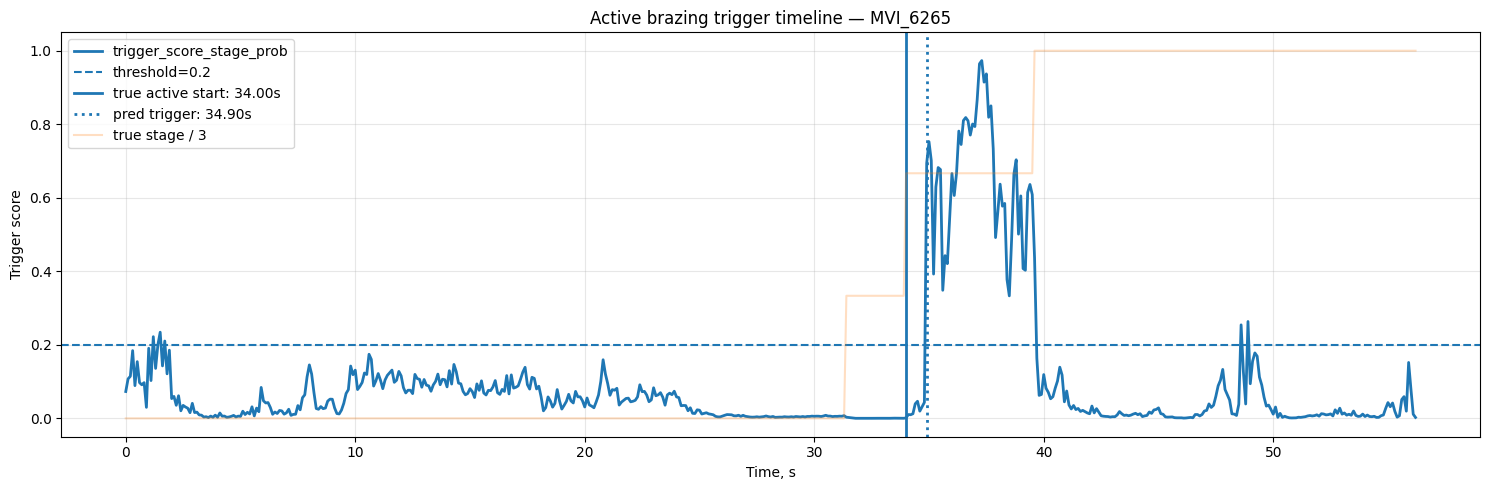

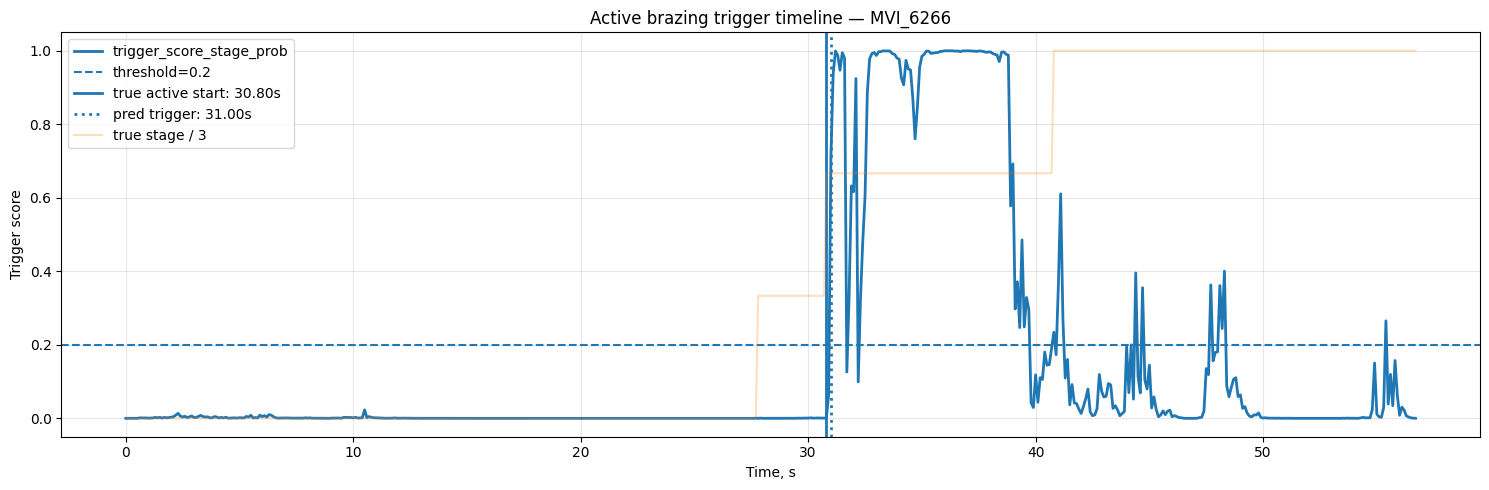

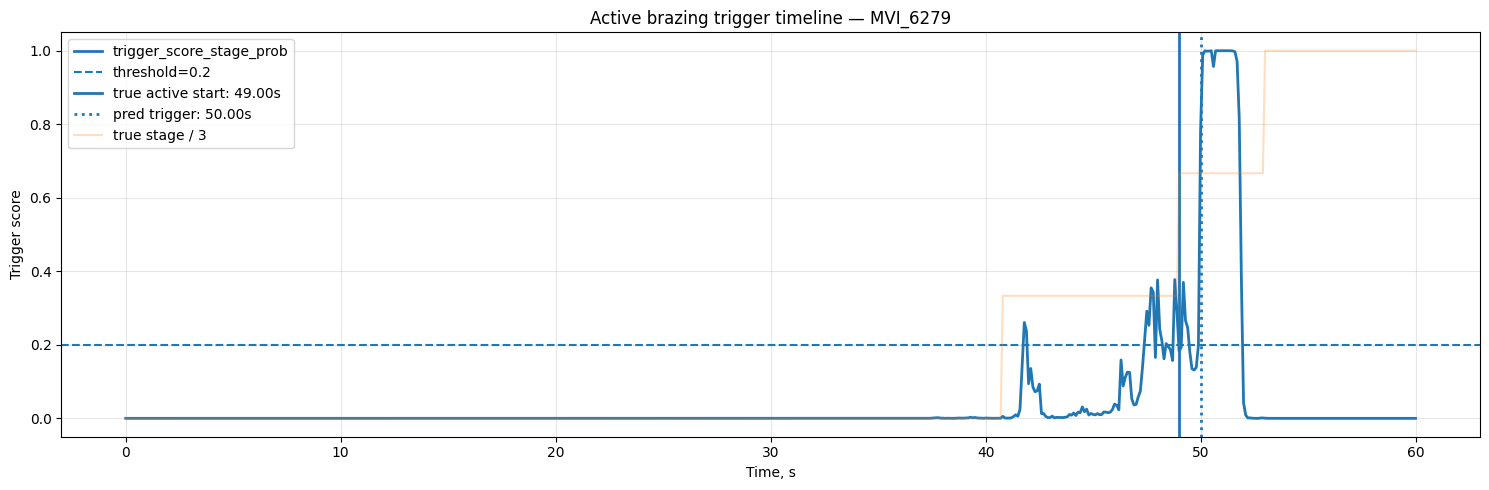

In [21]:
for video_id in sorted(trigger_df["video_id"].unique()):
    plot_trigger_timeline(
        trigger_df,
        true_active_start_df,
        video_id=video_id,
        score_col="trigger_score_stage_prob",
        threshold=float(best_stage_prob_trigger["threshold"]),
        confirm_frames=int(best_stage_prob_trigger["confirm_frames"]),
        output_name=f"{video_id}_stage_prob_trigger.png",
    )

## CV-trigger

In [22]:
cv_features_df = pd.read_csv(CV_FEATURES_PATH)
cv_features_df = cv_features_df.sort_values(["video_id", "timestamp_s"]).reset_index(drop=True)
print(cv_features_df.shape)
display(cv_features_df.head())

(10442, 27)


,video_id,frame_path,timestamp_s,stage_id,stage_name,brightness_mean,brightness_std,value_mean,value_std,saturation_mean,...,blue_mean,red_green_diff,red_blue_diff,white_area_ratio,specular_highlight_ratio,dark_area_ratio,warm_area_ratio,edge_density,laplacian_var,frame_diff_score
0,MVI_6265,data/processed/frames_10/MVI_6265/MVI_6265_000...,0.0,0,inactive_preparation,145.025702,56.764680,179.579174,59.605029,81.634146,...,178.895822,-24.509840,-54.469326,0.186183,0.295285,0.001684,0.000513,0.047298,63.083993,0.000000
1,MVI_6265,data/processed/frames_10/MVI_6265/MVI_6265_000...,0.1,0,inactive_preparation,145.016095,56.783864,179.602422,59.669960,81.694956,...,178.921460,-24.559415,-54.543208,0.184820,0.295854,0.002823,0.000104,0.044876,57.582917,5.643208
2,MVI_6265,data/processed/frames_10/MVI_6265/MVI_6265_000...,0.2,0,inactive_preparation,144.746600,56.941886,179.331492,59.928375,81.702783,...,178.628436,-24.466239,-54.456864,0.185397,0.295573,0.002326,0.001018,0.043881,52.329581,6.892799
3,MVI_6265,data/processed/frames_10/MVI_6265/MVI_6265_000...,0.3,0,inactive_preparation,144.179238,56.860416,178.766520,60.059887,81.878757,...,178.066095,-24.425670,-54.440866,0.182013,0.292221,0.002694,0.000217,0.045261,58.514641,6.039647
4,MVI_6265,data/processed/frames_10/MVI_6265/MVI_6265_000...,0.4,0,inactive_preparation,143.328941,56.569369,177.997971,60.045856,82.211307,...,177.244731,-24.299808,-54.387987,0.176135,0.283593,0.003144,0.000730,0.043111,55.663785,10.602550


### filter CV features to test videos

In [24]:
test_split_df = pd.read_csv(TEST_PATH)

if CV_FEATURES_PATH.exists():
    test_paths = set(test_split_df["frame_path"])

    cv_test_df = cv_features_df[
        cv_features_df["frame_path"].isin(test_paths)
    ].copy()

    cv_test_df = cv_test_df.sort_values(["video_id", "timestamp_s"]).reset_index(drop=True)

    cv_test_df["binary_active_brazing"] = (
        cv_test_df["stage_name"] == "active_brazing"
    ).astype(int)

    print(cv_test_df.shape)
    display(cv_test_df.head())

(1732, 28)


,video_id,frame_path,timestamp_s,stage_id,stage_name,brightness_mean,brightness_std,value_mean,value_std,saturation_mean,...,red_green_diff,red_blue_diff,white_area_ratio,specular_highlight_ratio,dark_area_ratio,warm_area_ratio,edge_density,laplacian_var,frame_diff_score,binary_active_brazing
0,MVI_6265,data/processed/frames_10/MVI_6265/MVI_6265_000...,0.0,0,inactive_preparation,145.025702,56.764680,179.579174,59.605029,81.634146,...,-24.509840,-54.469326,0.186183,0.295285,0.001684,0.000513,0.047298,63.083993,0.000000,0
1,MVI_6265,data/processed/frames_10/MVI_6265/MVI_6265_000...,0.1,0,inactive_preparation,145.016095,56.783864,179.602422,59.669960,81.694956,...,-24.559415,-54.543208,0.184820,0.295854,0.002823,0.000104,0.044876,57.582917,5.643208,0
2,MVI_6265,data/processed/frames_10/MVI_6265/MVI_6265_000...,0.2,0,inactive_preparation,144.746600,56.941886,179.331492,59.928375,81.702783,...,-24.466239,-54.456864,0.185397,0.295573,0.002326,0.001018,0.043881,52.329581,6.892799,0
3,MVI_6265,data/processed/frames_10/MVI_6265/MVI_6265_000...,0.3,0,inactive_preparation,144.179238,56.860416,178.766520,60.059887,81.878757,...,-24.425670,-54.440866,0.182013,0.292221,0.002694,0.000217,0.045261,58.514641,6.039647,0
4,MVI_6265,data/processed/frames_10/MVI_6265/MVI_6265_000...,0.4,0,inactive_preparation,143.328941,56.569369,177.997971,60.045856,82.211307,...,-24.299808,-54.387987,0.176135,0.283593,0.003144,0.000730,0.043111,55.663785,10.602550,0


### simple CV trigger score

Нормируем признаки внутри каждого видео, чтобы получить простой score.

In [26]:
def zscore_by_video(df: pd.DataFrame, col: str) -> pd.Series:
    values = []

    for video_id, video_df in df.groupby("video_id"):
        x = video_df[col].astype(float)
        std = x.std()

        if std == 0 or np.isnan(std):
            z = x * 0.0
        else:
            z = (x - x.mean()) / std

        values.append(z)

    return pd.concat(values).sort_index()

cv_trigger_df = cv_test_df.copy()

candidate_features = [
    "frame_diff_score",
    "laplacian_var",
    "edge_density",
    "specular_highlight_ratio",
]

for feature in candidate_features:
    cv_trigger_df[f"z_{feature}"] = zscore_by_video(cv_trigger_df, feature)

# Первый простой score: движение + текстура + границы.
cv_trigger_df["trigger_score_cv"] = (
    cv_trigger_df["z_frame_diff_score"]
    + cv_trigger_df["z_laplacian_var"]
    + cv_trigger_df["z_edge_density"]
    + 0.5 * cv_trigger_df["z_specular_highlight_ratio"]
)

# Приведём score в 0..1 внутри каждого видео.
normalized_parts = []

for video_id, video_df in cv_trigger_df.groupby("video_id"):
    video_df = video_df.copy()
    s = video_df["trigger_score_cv"]

    if s.max() > s.min():
        video_df["trigger_score_cv_norm"] = (s - s.min()) / (s.max() - s.min())
    else:
        video_df["trigger_score_cv_norm"] = 0.0

    normalized_parts.append(video_df)

cv_trigger_df = pd.concat(normalized_parts).sort_values(
    ["video_id", "timestamp_s"]
).reset_index(drop=True)

cv_trigger_df[[
    "video_id",
    "timestamp_s",
    "stage_name",
    "trigger_score_cv_norm",
]].head()

,video_id,timestamp_s,stage_name,trigger_score_cv_norm
0,MVI_6265,0.0,inactive_preparation,0.033520
1,MVI_6265,0.1,inactive_preparation,0.232004
2,MVI_6265,0.2,inactive_preparation,0.179854
3,MVI_6265,0.3,inactive_preparation,0.281826
4,MVI_6265,0.4,inactive_preparation,0.468756


### grid search

In [27]:
grid_rows = []

thresholds = [0.4, 0.5, 0.6, 0.7, 0.8]
confirm_frames_values = [1, 2, 3, 5, 7, 10]

for threshold in thresholds:
    for confirm_frames in confirm_frames_values:
        candidate_event_df = evaluate_event_trigger(
            cv_trigger_df,
            true_active_start_df,
            score_col="trigger_score_cv_norm",
            threshold=threshold,
            confirm_frames=confirm_frames,
        )

        summary = summarize_event_results(candidate_event_df)

        grid_rows.append({
            "score_col": "trigger_score_cv_norm",
            "threshold": threshold,
            "confirm_frames": confirm_frames,
            **summary,
        })

cv_rule_grid_df = pd.DataFrame(grid_rows).sort_values(
    ["mae_s", "num_missed", "max_abs_error_s"],
    ascending=[True, True, True],
)

display(cv_rule_grid_df.head(20))

cv_rule_grid_df.to_csv(
    OUTPUT_DIR / "cv_rule_trigger_grid.csv",
    index=False,
)

,score_col,threshold,confirm_frames,num_videos,num_detected,num_missed,num_early,num_late,mae_s,mean_error_s,median_abs_error_s,max_abs_error_s,within_1.0s,within_2.0s
9,trigger_score_cv_norm,0.5,5,3,3,0,1,2,0.900000,-0.300000,0.6,1.8,0.666667,1.000000
10,trigger_score_cv_norm,0.5,7,3,3,0,1,2,0.900000,-0.300000,0.6,1.8,0.666667,1.000000
11,trigger_score_cv_norm,0.5,10,3,3,0,1,2,0.900000,-0.300000,0.6,1.8,0.666667,1.000000
13,trigger_score_cv_norm,0.6,2,3,3,0,0,3,1.066667,1.066667,1.4,1.4,0.333333,1.000000
14,trigger_score_cv_norm,0.6,3,3,3,0,0,3,1.566667,1.566667,1.4,2.6,0.333333,0.666667
15,trigger_score_cv_norm,0.6,5,3,3,0,0,3,1.566667,1.566667,1.4,2.6,0.333333,0.666667
18,trigger_score_cv_norm,0.7,1,3,3,0,0,3,1.700000,1.700000,1.4,2.8,0.333333,0.666667
19,trigger_score_cv_norm,0.7,2,3,3,0,0,3,1.766667,1.766667,1.4,2.8,0.000000,0.666667
16,trigger_score_cv_norm,0.6,7,3,3,0,0,3,1.866667,1.866667,1.4,3.5,0.333333,0.666667
17,trigger_score_cv_norm,0.6,10,3,3,0,0,3,1.866667,1.866667,1.4,3.5,0.333333,0.666667


### cv trigger timelines

In [28]:
best_cv_rule_trigger = cv_rule_grid_df.iloc[0].to_dict()
best_cv_rule_trigger

{'score_col': 'trigger_score_cv_norm',
 'threshold': 0.5,
 'confirm_frames': 5,
 'num_videos': 3,
 'num_detected': 3,
 'num_missed': 0,
 'num_early': 1,
 'num_late': 2,
 'mae_s': 0.8999999999999974,
 'mean_error_s': -0.3000000000000007,
 'median_abs_error_s': 0.5999999999999979,
 'max_abs_error_s': 1.7999999999999972,
 'within_1.0s': 0.6666666666666666,
 'within_2.0s': 1.0}

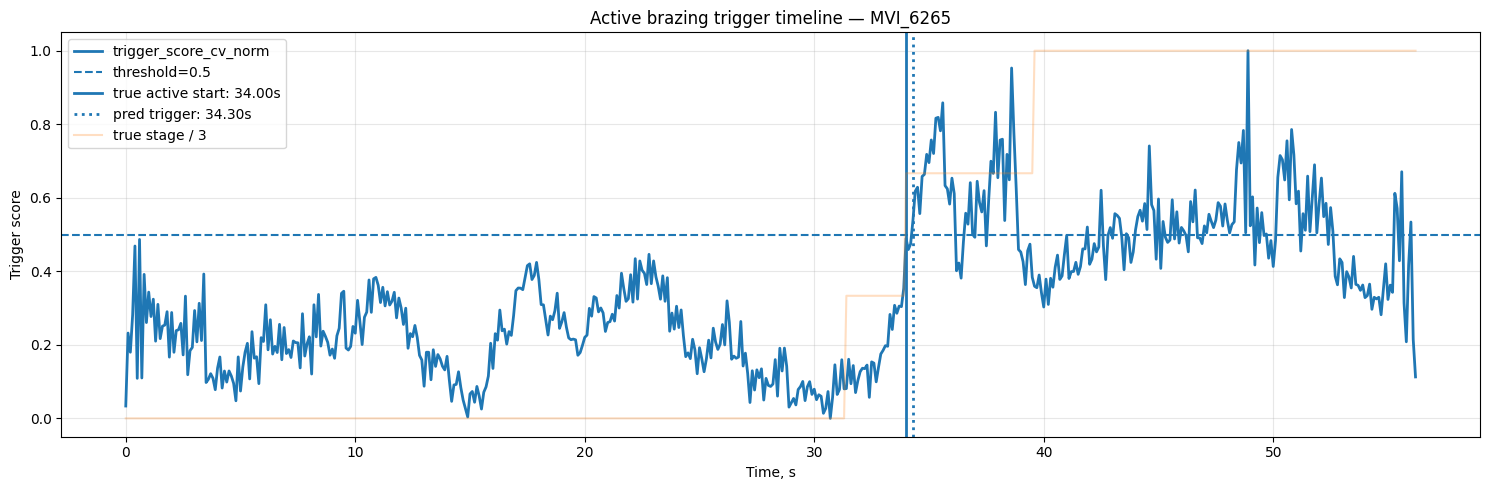

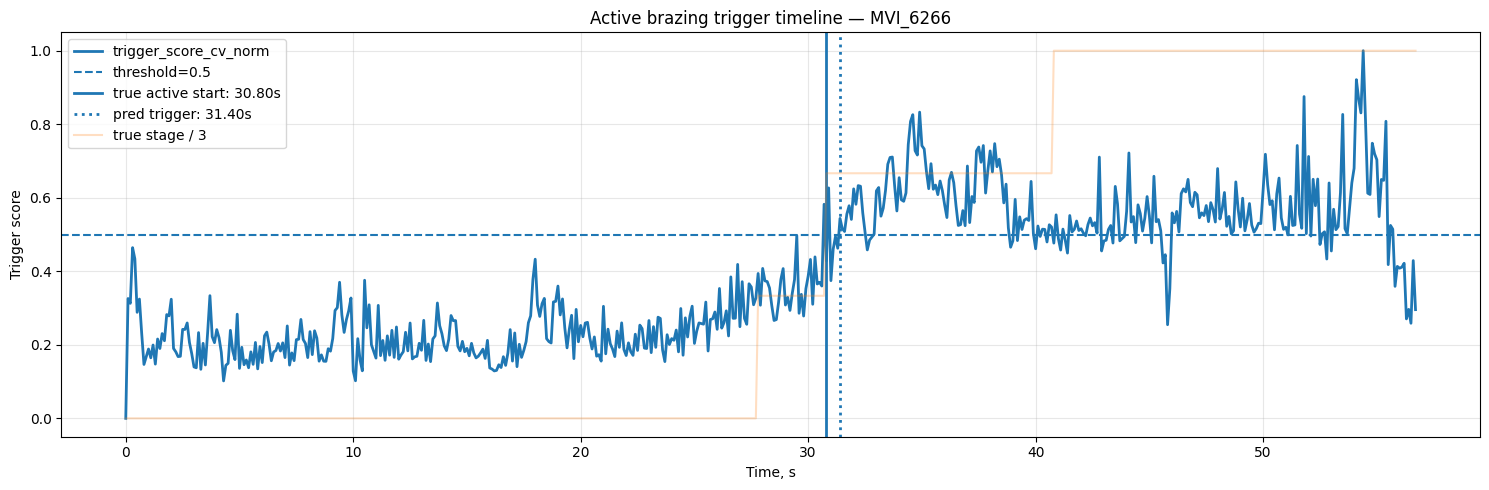

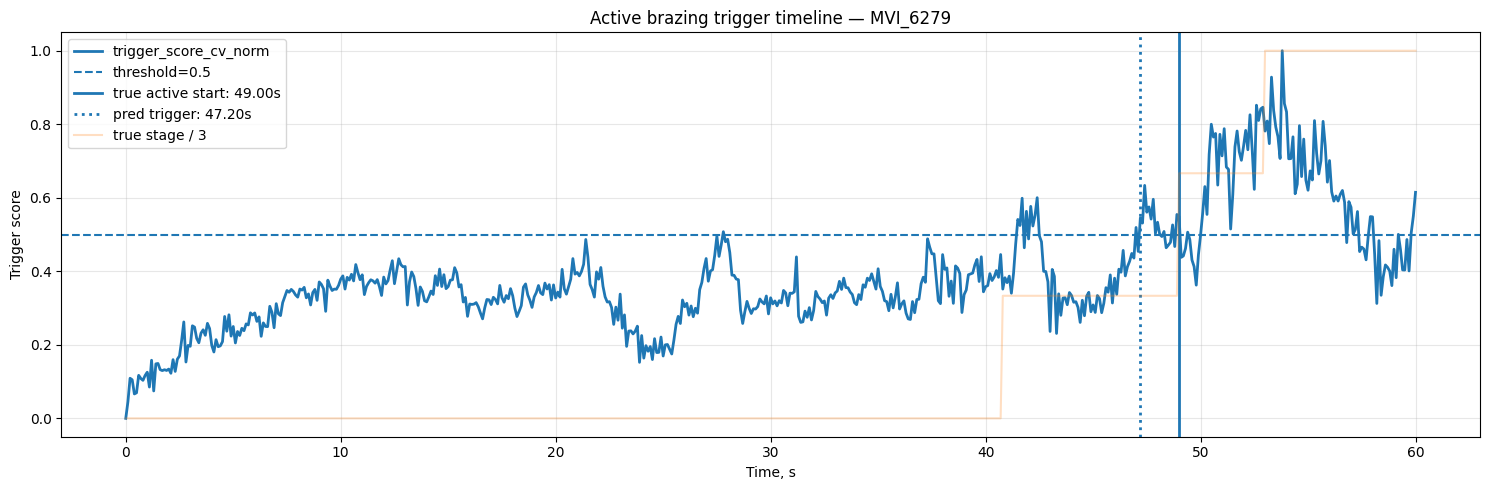

In [29]:
for video_id in sorted(cv_trigger_df["video_id"].unique()):
    plot_trigger_timeline(
        cv_trigger_df,
        true_active_start_df,
        video_id=video_id,
        score_col="trigger_score_cv_norm",
        threshold=float(best_cv_rule_trigger["threshold"]),
        confirm_frames=int(best_cv_rule_trigger["confirm_frames"]),
        output_name=f"{video_id}_cv_rule_trigger.png",
    )

## Classical ML binary trigger on CV features

In [30]:
train_split_df = pd.read_csv(TRAIN_PATH)
val_split_df = pd.read_csv(VAL_PATH)
test_split_df = pd.read_csv(TEST_PATH)

train_paths = set(train_split_df["frame_path"])
val_paths = set(val_split_df["frame_path"])
test_paths = set(test_split_df["frame_path"])

cv_train_df = cv_features_df[cv_features_df["frame_path"].isin(train_paths)].copy()
cv_val_df = cv_features_df[cv_features_df["frame_path"].isin(val_paths)].copy()
cv_test_df = cv_features_df[cv_features_df["frame_path"].isin(test_paths)].copy()

for part_df in [cv_train_df, cv_val_df, cv_test_df]:
    part_df["binary_active_brazing"] = (
        part_df["stage_name"] == "active_brazing"
    ).astype(int)

print(cv_train_df.shape, cv_val_df.shape, cv_test_df.shape)

(5755, 28) (1091, 28) (1732, 28)


In [31]:
META_COLUMNS = {
    "video_id",
    "frame_path",
    "timestamp_s",
    "stage_id",
    "stage_name",
    "binary_active_brazing",
}

cv_feature_columns = [
    col for col in cv_features_df.columns
    if col not in META_COLUMNS
]

cv_feature_columns

['brightness_mean',
 'brightness_std',
 'value_mean',
 'value_std',
 'saturation_mean',
 'saturation_std',
 'hue_mean',
 'lab_l_mean',
 'lab_a_mean',
 'lab_b_mean',
 'red_mean',
 'green_mean',
 'blue_mean',
 'red_green_diff',
 'red_blue_diff',
 'white_area_ratio',
 'specular_highlight_ratio',
 'dark_area_ratio',
 'warm_area_ratio',
 'edge_density',
 'laplacian_var',
 'frame_diff_score']

### train

In [32]:
X_train = cv_train_df[cv_feature_columns].replace([np.inf, -np.inf], np.nan)
X_val = cv_val_df[cv_feature_columns].replace([np.inf, -np.inf], np.nan)
X_test = cv_test_df[cv_feature_columns].replace([np.inf, -np.inf], np.nan)

median_values = X_train.median()

X_train = X_train.fillna(median_values).values
X_val = X_val.fillna(median_values).values
X_test = X_test.fillna(median_values).values

y_train = cv_train_df["binary_active_brazing"].values
y_val = cv_val_df["binary_active_brazing"].values
y_test = cv_test_df["binary_active_brazing"].values

binary_models = {
    "LogisticRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            random_state=42,
        )),
    ]),
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=3,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    ),
    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42,
    ),
}

binary_model_rows = []

for name, model in binary_models.items():
    model.fit(X_train, y_train)
    val_pred = model.predict(X_val)

    binary_model_rows.append({
        "model": name,
        "val_accuracy": accuracy_score(y_val, val_pred),
        "val_precision": precision_score(y_val, val_pred, zero_division=0),
        "val_recall": recall_score(y_val, val_pred, zero_division=0),
        "val_f1": f1_score(y_val, val_pred, zero_division=0),
    })

binary_model_metrics_df = pd.DataFrame(binary_model_rows).sort_values(
    "val_f1",
    ascending=False,
)

binary_model_metrics_df

,model,val_accuracy,val_precision,val_recall,val_f1
1,RandomForest,0.906508,0.623288,0.659420,0.640845
2,GradientBoosting,0.900092,0.605839,0.601449,0.603636
0,LogisticRegression,0.868011,0.486239,0.768116,0.595506


### test best

Best CV binary model: RandomForest
                    precision    recall  f1-score   support

not_active_brazing     0.9368    0.9355    0.9362      1536
    active_brazing     0.5000    0.5051    0.5025       196

          accuracy                         0.8868      1732
         macro avg     0.7184    0.7203    0.7193      1732
      weighted avg     0.8873    0.8868    0.8871      1732



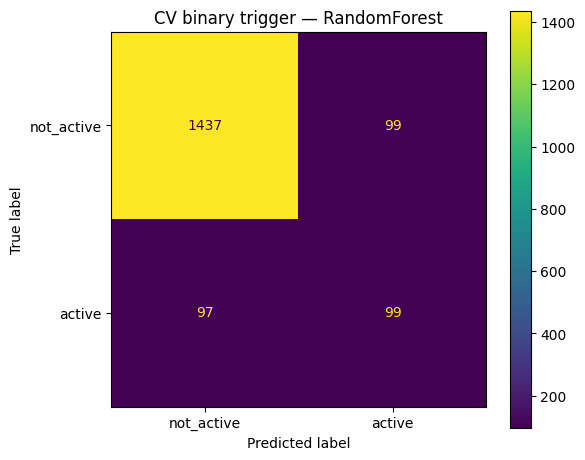

In [33]:
best_binary_model_name = binary_model_metrics_df.iloc[0]["model"]
best_binary_model = binary_models[best_binary_model_name]

test_pred = best_binary_model.predict(X_test)

print(f"Best CV binary model: {best_binary_model_name}")
print(classification_report(
    y_test,
    test_pred,
    target_names=["not_active_brazing", "active_brazing"],
    digits=4,
    zero_division=0,
))

cm = confusion_matrix(y_test, test_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["not_active", "active"],
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, values_format="d")
ax.set_title(f"CV binary trigger — {best_binary_model_name}")
plt.tight_layout()
plt.show()

### event timing

In [34]:
if hasattr(best_binary_model, "predict_proba"):
    test_score = best_binary_model.predict_proba(X_test)[:, 1]
else:
    test_score = best_binary_model.predict(X_test)

cv_binary_trigger_df = cv_test_df.copy()
cv_binary_trigger_df["trigger_score_cv_binary_model"] = test_score

cv_binary_grid_rows = []

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
confirm_frames_values = [1, 2, 3, 5, 7, 10]

for threshold in thresholds:
    for confirm_frames in confirm_frames_values:
        candidate_event_df = evaluate_event_trigger(
            cv_binary_trigger_df,
            true_active_start_df,
            score_col="trigger_score_cv_binary_model",
            threshold=threshold,
            confirm_frames=confirm_frames,
        )

        summary = summarize_event_results(candidate_event_df)

        cv_binary_grid_rows.append({
            "score_col": "trigger_score_cv_binary_model",
            "threshold": threshold,
            "confirm_frames": confirm_frames,
            **summary,
        })

cv_binary_grid_df = pd.DataFrame(cv_binary_grid_rows).sort_values(
    ["mae_s", "num_missed", "max_abs_error_s"],
    ascending=[True, True, True],
)

display(cv_binary_grid_df.head(20))

cv_binary_grid_df.to_csv(
    OUTPUT_DIR / "cv_binary_model_trigger_grid.csv",
    index=False,
)

,score_col,threshold,confirm_frames,num_videos,num_detected,num_missed,num_early,num_late,mae_s,mean_error_s,median_abs_error_s,max_abs_error_s,within_1.0s,within_2.0s
22,trigger_score_cv_binary_model,0.6,7,3,2,1,0,2,0.95,0.950000,0.95,1.5,0.500000,1.000000
23,trigger_score_cv_binary_model,0.6,10,3,2,1,0,2,0.95,0.950000,0.95,1.5,0.500000,1.000000
27,trigger_score_cv_binary_model,0.7,5,3,2,1,0,2,1.05,1.050000,1.05,1.5,0.500000,1.000000
28,trigger_score_cv_binary_model,0.7,7,3,2,1,0,2,1.05,1.050000,1.05,1.5,0.500000,1.000000
29,trigger_score_cv_binary_model,0.7,10,3,2,1,0,2,1.05,1.050000,1.05,1.5,0.500000,1.000000
17,trigger_score_cv_binary_model,0.5,10,3,2,1,1,1,2.35,-1.950000,2.35,4.3,0.500000,0.500000
16,trigger_score_cv_binary_model,0.5,7,3,2,1,1,1,2.85,-2.450000,2.85,5.3,0.500000,0.500000
24,trigger_score_cv_binary_model,0.7,1,3,2,1,1,1,3.70,-3.300000,3.70,7.0,0.500000,0.500000
13,trigger_score_cv_binary_model,0.5,2,3,2,1,1,1,3.75,-3.350000,3.75,7.1,0.500000,0.500000
14,trigger_score_cv_binary_model,0.5,3,3,2,1,1,1,3.75,-3.350000,3.75,7.1,0.500000,0.500000


### timeline

In [37]:
best_cv_binary_trigger = cv_binary_grid_df.iloc[0].to_dict()
best_cv_binary_trigger

{'score_col': 'trigger_score_cv_binary_model',
 'threshold': 0.6,
 'confirm_frames': 7,
 'num_videos': 3,
 'num_detected': 2,
 'num_missed': 1,
 'num_early': 0,
 'num_late': 2,
 'mae_s': 0.9499999999999993,
 'mean_error_s': 0.9499999999999993,
 'median_abs_error_s': 0.9499999999999993,
 'max_abs_error_s': 1.5,
 'within_1.0s': 0.5,
 'within_2.0s': 1.0}

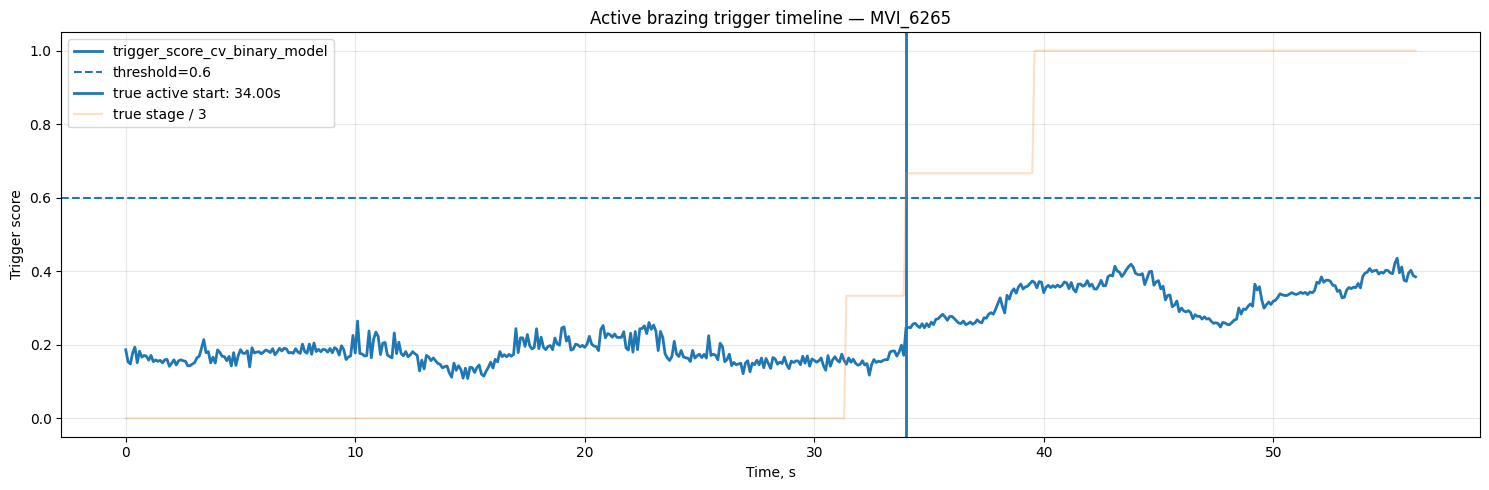

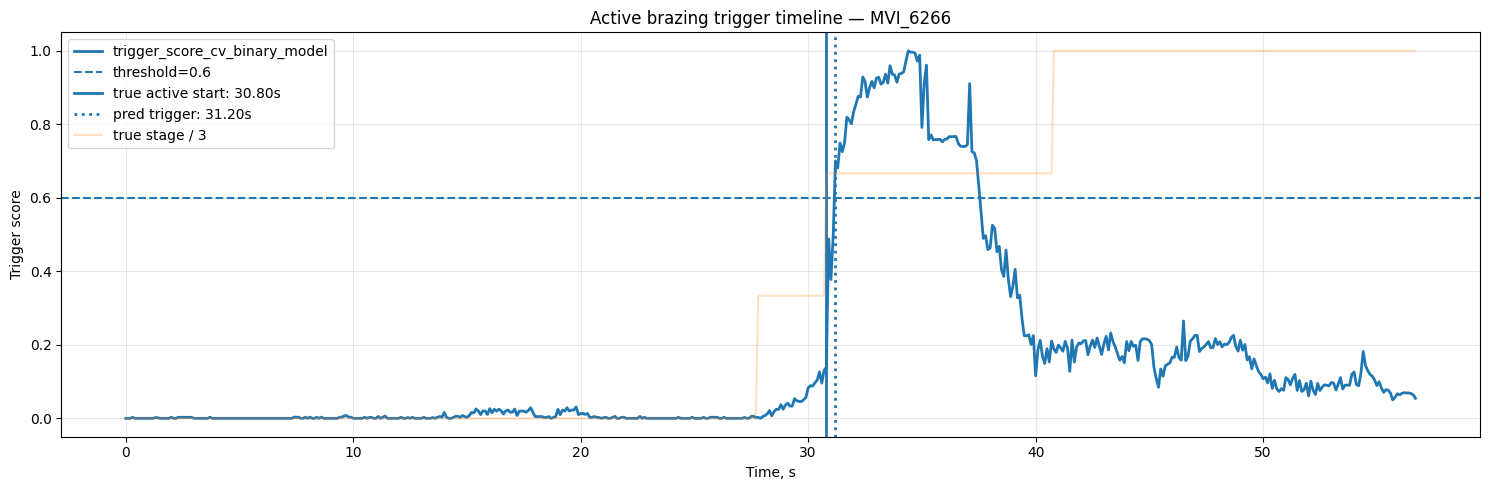

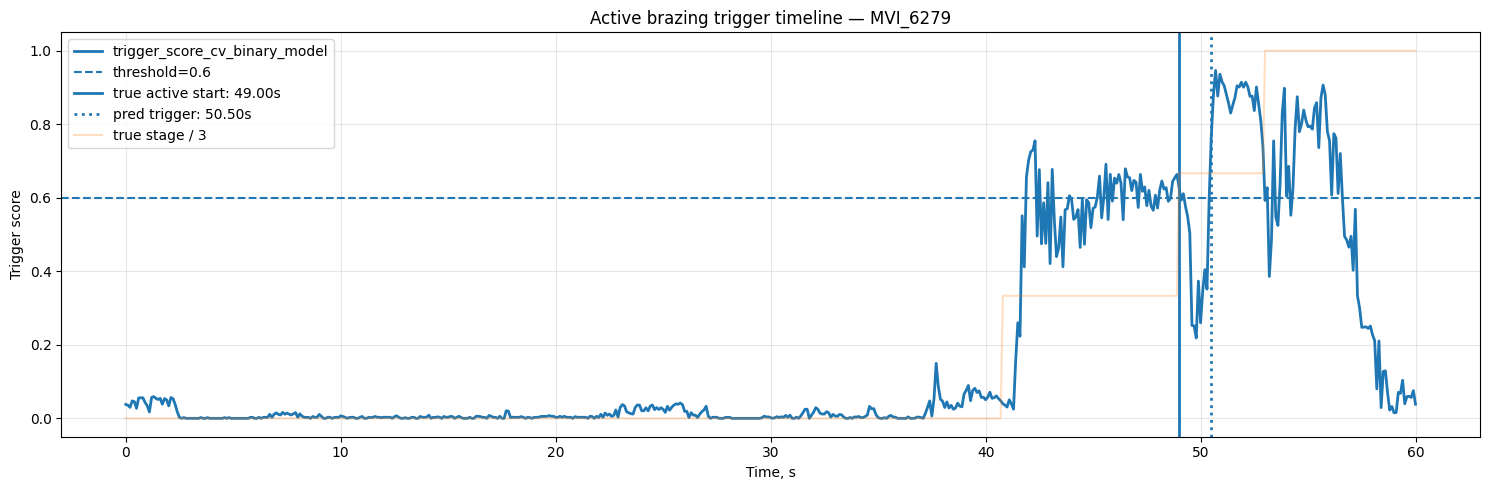

In [38]:
for video_id in sorted(cv_binary_trigger_df["video_id"].unique()):
    plot_trigger_timeline(
        cv_binary_trigger_df,
        true_active_start_df,
        video_id=video_id,
        score_col="trigger_score_cv_binary_model",
        threshold=float(best_cv_binary_trigger["threshold"]),
        confirm_frames=int(best_cv_binary_trigger["confirm_frames"]),
        output_name=f"{video_id}_cv_binary_model_trigger.png",
    )

## comprasion

In [35]:
summary_rows = []

best_stage_prob_summary = summarize_event_results(
    evaluate_event_trigger(
        trigger_df,
        true_active_start_df,
        score_col="trigger_score_stage_prob",
        threshold=float(best_stage_prob_trigger["threshold"]),
        confirm_frames=int(best_stage_prob_trigger["confirm_frames"]),
    )
)

summary_rows.append({
    "method": "stage_model_prob_active_brazing",
    "threshold": float(best_stage_prob_trigger["threshold"]),
    "confirm_frames": int(best_stage_prob_trigger["confirm_frames"]),
    **best_stage_prob_summary,
})

best_cv_rule_summary = summarize_event_results(
    evaluate_event_trigger(
        cv_trigger_df,
        true_active_start_df,
        score_col="trigger_score_cv_norm",
        threshold=float(best_cv_rule_trigger["threshold"]),
        confirm_frames=int(best_cv_rule_trigger["confirm_frames"]),
    )
)

summary_rows.append({
    "method": "cv_rule_trigger",
    "threshold": float(best_cv_rule_trigger["threshold"]),
    "confirm_frames": int(best_cv_rule_trigger["confirm_frames"]),
    **best_cv_rule_summary,
})

best_cv_binary_summary = summarize_event_results(
    evaluate_event_trigger(
        cv_binary_trigger_df,
        true_active_start_df,
        score_col="trigger_score_cv_binary_model",
        threshold=float(cv_binary_grid_df.iloc[0]["threshold"]),
        confirm_frames=int(cv_binary_grid_df.iloc[0]["confirm_frames"]),
    )
)

summary_rows.append({
    "method": f"cv_binary_model_{best_binary_model_name}",
    "threshold": float(cv_binary_grid_df.iloc[0]["threshold"]),
    "confirm_frames": int(cv_binary_grid_df.iloc[0]["confirm_frames"]),
    **best_cv_binary_summary,
})

trigger_methods_summary_df = pd.DataFrame(summary_rows)
trigger_methods_summary_df

,method,threshold,confirm_frames,num_videos,num_detected,num_missed,num_early,num_late,mae_s,mean_error_s,median_abs_error_s,max_abs_error_s,within_1.0s,within_2.0s
0,stage_model_prob_active_brazing,0.2,7,3,3,0,0,3,0.70,0.70,0.90,1.0,1.000000,1.0
1,cv_rule_trigger,0.5,5,3,3,0,1,2,0.90,-0.30,0.60,1.8,0.666667,1.0
2,cv_binary_model_RandomForest,0.6,7,3,2,1,0,2,0.95,0.95,0.95,1.5,0.500000,1.0


In [36]:
trigger_methods_summary_df.to_csv(
    OUTPUT_DIR / "trigger_methods_summary.csv",
    index=False,
)

# results

Итоговый вывод по active_brazing trigger

В данном ноутбуке была рассмотрена отдельная задача детекции события начала активной пайки. В отличие от задачи определения текущей стадии процесса, здесь основной метрикой является не покадровая точность, а ошибка времени срабатывания относительно размеченного начала стадии `active_brazing`.

Были проверены три подхода:

1. Триггер на основе вероятности `P(active_brazing)` финальной stage-модели.
2. Правило на основе OpenCV-признаков ROI.
3. Бинарный classical ML trigger на OpenCV-признаках.

Лучший результат показал триггер на основе вероятности `P(active_brazing)`:

```text
threshold:      0.2
confirm_frames: 7
num_detected:   3/3
num_missed:     0
num_early:      0
num_late:       3
MAE:            0.70 s
max_abs_error:  1.0 s
within_1.0s:    100%
within_2.0s:    100%
````

Таким образом, событие начала активной пайки может быть надёжно выделено из вероятностей уже обученной модели определения стадий. Такой подход не требует обучения отдельной бинарной нейросети и использует уже существующий stage-classifier.

OpenCV-trigger также показал работоспособность как объяснимый baseline:

```text
CV rule trigger:
MAE:          0.90 s
num_detected: 3/3
within_1.0s: 66.7%
within_2.0s: 100%
```

Однако он уступает триггеру на основе вероятности `P(active_brazing)` по точности времени срабатывания.

Бинарный trigger на OpenCV-признаках показал менее устойчивый результат: один из трёх тестовых роликов не был обнаружен, поэтому данный подход не рассматривается как основной.

Итог: для быстрого управляющего события целесообразно использовать отдельный trigger-слой поверх stage-classifier:

```text
ResNet18 stage classifier
→ P(active_brazing)
→ threshold + confirmation over N frames
→ active_brazing_started
```

При выбранных параметрах `threshold = 0.2` и `confirm_frames = 7` триггер срабатывает на всех тестовых видео с ошибкой не более 1 секунды. Это делает его перспективным вспомогательным сигналом для будущей логики фиксации температуры или уведомления оператора о начале активной пайки.

````

## Финальная архитектура теперь очень красивая

```text id="kpp7o4"
1. Stage monitoring:
   ResNet18 → state machine → stable operator stage

2. Active brazing trigger:
   ResNet18 → P(active_brazing) → threshold + 7-frame confirmation
````